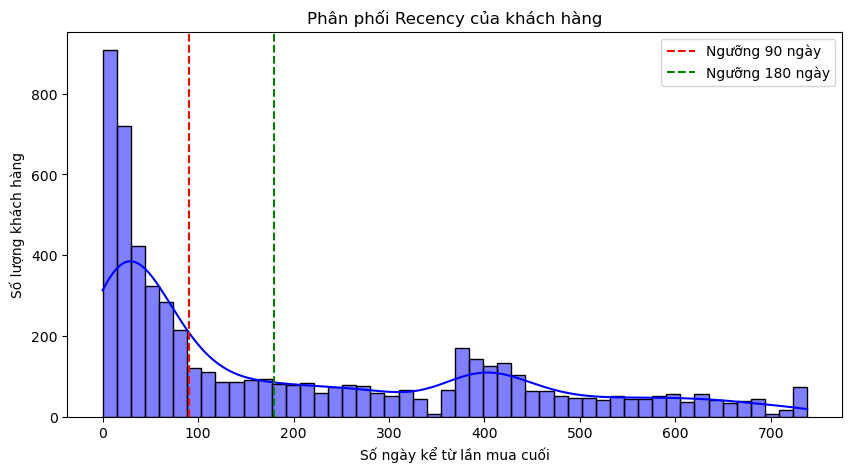

Thống kê Recency:
count    5878.000000
mean      200.866791
std       209.353961
min         0.000000
25%        25.000000
50%        95.000000
75%       379.000000
max       738.000000
Name: Recency, dtype: float64

Tỷ lệ Churn với ngưỡng 180 ngày:
is_churn
0    0.592038
1    0.407962
Name: proportion, dtype: float64


C:\Users\QUYNH KHA\AppData\Local\Temp\ipykernel_27560\157844523.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_churn', data=df, palette='viridis')


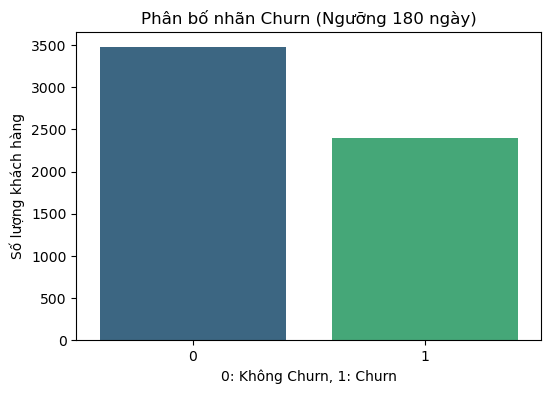


✅ Đã lưu ../data/processed/customer_features_labeled.csv thành công!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu từ bước 3.4
input_path = '../data/processed/customer_features.csv'
output_path = '../data/processed/customer_features_labeled.csv'

df = pd.read_csv(input_path)

# 2. EDA phân phối Recency (CỰC KỲ QUAN TRỌNG)
plt.figure(figsize=(10, 5))
sns.histplot(df['Recency'], bins=50, kde=True, color='blue')
plt.title('Phân phối Recency của khách hàng')
plt.xlabel('Số ngày kể từ lần mua cuối')
plt.ylabel('Số lượng khách hàng')
plt.axvline(x=90, color='red', linestyle='--', label='Ngưỡng 90 ngày')
plt.axvline(x=180, color='green', linestyle='--', label='Ngưỡng 180 ngày')
plt.legend()
plt.show()

# In ra các giá trị thống kê của Recency
print("Thống kê Recency:")
print(df['Recency'].describe())

# 3. Chọn ngưỡng (Threshold)
# Dựa trên đặc thù B2B của Online Retail II, ngưỡng 180 ngày (6 tháng) thường hợp lý.
threshold = 180  

df['is_churn'] = np.where(df['Recency'] > threshold, 1, 0)

# 4. Kiểm tra mất cân bằng lớp
print(f"\nTỷ lệ Churn với ngưỡng {threshold} ngày:")
print(df['is_churn'].value_counts(normalize=True))

# Vẽ biểu đồ so sánh
plt.figure(figsize=(6, 4))
sns.countplot(x='is_churn', data=df, palette='viridis')
plt.title(f'Phân bố nhãn Churn (Ngưỡng {threshold} ngày)')
plt.xlabel('0: Không Churn, 1: Churn')
plt.ylabel('Số lượng khách hàng')
plt.show()

# 5. Lưu Output bắt buộc
df.to_csv(output_path, index=False)
print(f"\n✅ Đã lưu {output_path} thành công!")